***N.B. this notebook has been tested in Google Colab***


# Handwritten Digit Classification

In this project, you will build a machine learning algorithm to classify handwritten digits using image features. Starting with the provided dataset, your task is to develop a model that effectively solves this multiclass classification problem. Use the baseline notebook as a starting point and improve upon it.

***Overall Goal: to design a complete pipeline that improves accuracy from the current 52% to at least 92%, ideally approaching 97-98%***


## Introduction

In this project, you will work with a dataset of handwritten digit images. The dataset has been intentionally made messy: some images are missing labels, others are noisy or empty, and certain classes have more samples than others. Your task is to clean and organize this dataset to prepare it for analysis.

A basic, weak baseline model is provided to help you get started. This baseline is not intended to be accurate or comprehensive. Instead, it’s a starting point for you to improve upon by applying your own strategies to enhance data quality and model performance.

Formal details and specific tasks will be outlined at the end of this notebook. For now, focus on understanding the dataset and planning how to address its challenges.

**We expect you to submit a modified version of this notebook with your improvements. Please download a copy of this assignment in your private Python programming environment, before making any changes.**

## Baseline

Let's install all required dependencies:

- **datasets**: Provides access to large-scale datasets, including the one you'll work with.
- **scikit-learn**: Tools for classical machine learning algorithms and model evaluation.
- **matplotlib**: Plotting library for data visualization.
- **opencv-python**: Computer vision library for image processing.
- **scikit-image**: Image processing tools specifically designed for scientific tasks.
- **tqdm**: Displays progress bars to track loops and long operations.
- **pillow**: Image processing library

You might be familiar with most of these already.

In [1]:
%%capture
!pip install datasets==3.5.0 scikit-learn matplotlib opencv-python scikit-image pillow

And import the modules

In [2]:
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from skimage.feature import hog, local_binary_pattern
from sklearn.preprocessing import StandardScaler
import cv2
from tqdm import tqdm

### Dataset Description

The dataset consists of images of handwritten digits from 10 classes, representing the digits `0` through `9`. These images are grayscale and have been resized to a standard size (e.g., 28x28 pixels).

The dataset has been purposely modified to include some **unlabeled images**, **noisy samples**, and **synthetically augmented data** for certain classes. You will need to clean the data, handle the noise, and ensure that the dataset is ready for effective model training.

Basic preprocessing has been provided, but more advanced data cleaning and feature extraction will be a key part of your assignment.

Let's download the dataset using the Hugging Face datasets library and display first samples.

In [3]:
dataset = load_dataset("unibz-ds-course/image_assignment")
first_samples = dataset['train'].select(range(25))

images = first_samples['image']
labels = first_samples['label']


In [4]:
# function to display rows * cols first samples from images
def show_grid(images, labels, rows=5, cols=5, figsize=(8, 5), cmap='gray'):
    if len(images) != len(labels):
        print("Warning: number of images and labels isn't the same.")

    total_slots = rows * cols
    n = len(images)

    if n == 0:
        print("Warning: no images to display.")
        return
    elif n < total_slots:
        print(f"Warning: only {n} images provided, but grid has {total_slots} slots.")

    fig, axs = plt.subplots(rows, cols, figsize=figsize)
    axs = axs.flat

    for i in range(total_slots):
        ax = axs[i]
        if i < n:
            ax.imshow(np.array(images[i]), cmap=cmap)
            ax.set_title(f"Label: {labels[i]}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

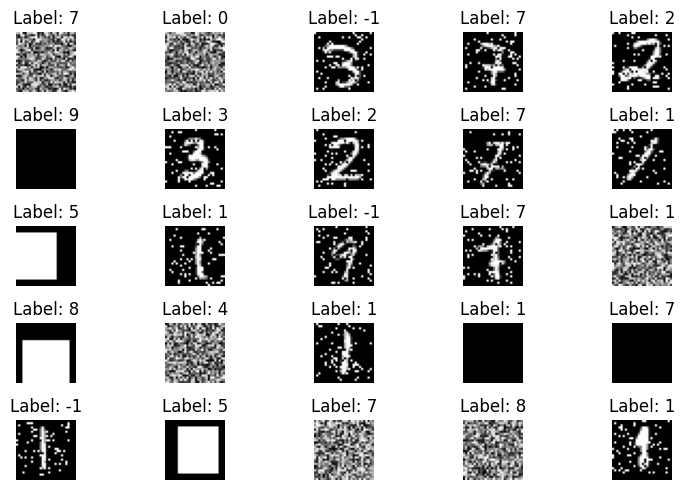

In [5]:
show_grid(images, labels)

As we can see, the dataset contains various types of irrelevant images, such as empty images, unlabeled samples (**labeled as -1**), noisy images, and images containing large rectangles.

These artifacts were intentionally introduced and will need to be identified and filtered out during the data cleaning process.

**During filtering, display a subset of the removed images (the code to display is already written). It is recommended to display at least 20–30 to ensure that images containing numbers are not mistakenly filtered out. Also, important to pass to each step of filtering result from previous: all this is already implemented, just make sure not to change this behaviour.**

Additionally, based on these initial samples, we can anticipate some imbalance in the dataset, which will require careful handling to ensure fair and accurate model training.


**Draw a plot with distribution of the classes (5 points)**

Create a visualization (e.g., bar chart or histogram) that shows how many samples belong to each class. This helps identify whether the dataset is balanced or if some classes are underrepresented.

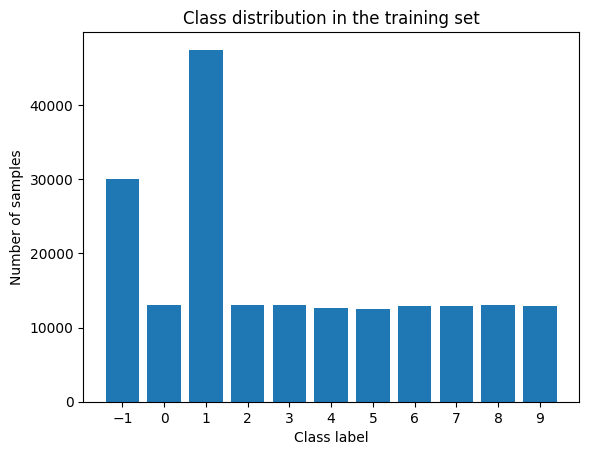

In [6]:
# write code to draw the distribution
from collections import Counter

labels = dataset["train"]["label"]
counts = Counter(labels)

classes = sorted(counts.keys())
values = [counts[c] for c in classes]

plt.bar(classes, values)
plt.xticks(classes)
plt.xlabel("Class label")
plt.ylabel("Number of samples")
plt.title("Class distribution in the training set")
plt.show()

MDR : In this dataset, the label -1 represents samples that do not belong to any valid class.
In practice, this usually means one of the following:
- Invalid / corrupted samples
- Unlabeled images
- Background / noise images
- Images that could not be assigned to any of the 0–9 classes

So, unlike 0–9, -1 is a “special” label, not a real class you want the model to learn.

### Data cleaning

During data cleaning it's important to display which samples we've filtered out and which kept.
To do it we define a helper function. It iterates over dataset twice and returns two datasets: clean and filterd by predicate.
You can rewrite it with a single for-loop (but it's not necessary to do and you need to make sure to iterate over all split sets in the dataset)

**Let's filter out unlabeled samples**

In [7]:
# filters out samples which do not match by predicate and returns cleaned and filtered datasets
def filter_dataset(ds, predicate):
    cleaned_ds = ds.filter(lambda e: not predicate(e))
    filtered_ds = ds.filter(lambda e: predicate(e))
    return cleaned_ds, filtered_ds

In [8]:
# predicate for removing unlabeled samples. Similiarly you are supposed to write other predicates
def is_unlabeled(sample):
    return sample['label'] == -1

In [9]:
dataset_wo_unlabeled, unlabeled_samples = filter_dataset(dataset, is_unlabeled)

Filter:   0%|          | 0/193710 [00:00<?, ? examples/s]

Filter:   0%|          | 0/32341 [00:00<?, ? examples/s]

Filter:   0%|          | 0/193710 [00:00<?, ? examples/s]

Filter:   0%|          | 0/32341 [00:00<?, ? examples/s]

Let's display our cleaned dataset and samples that we have filtered out. It's recommended to take a look also at test set to make sure it's properly cleaned as well.

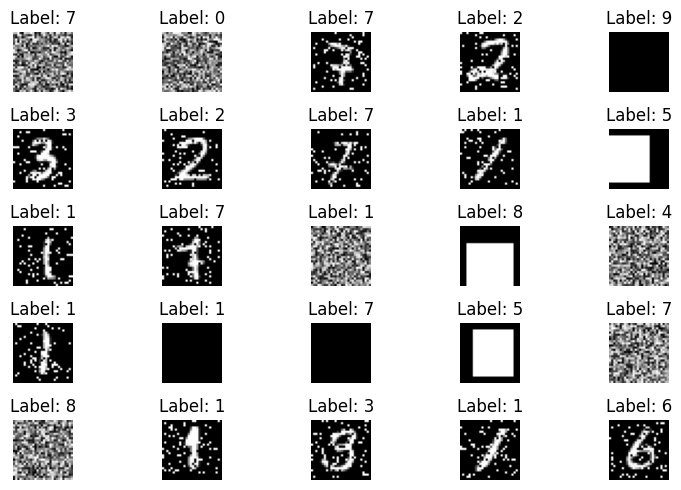

In [10]:
show_grid(dataset_wo_unlabeled['train']['image'], dataset_wo_unlabeled['train']['label'])

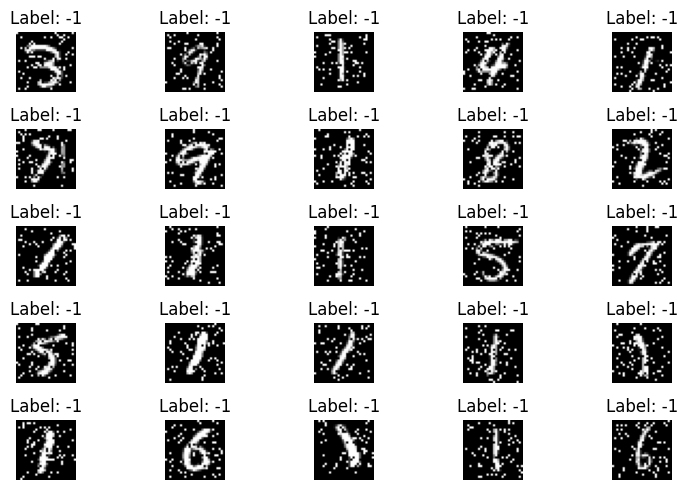

In [11]:
show_grid(unlabeled_samples['train']['image'], unlabeled_samples['train']['label'])

**Filter out empty images (5 points)**

Implement **is_empty** predicate.

Here we want to remove only images which contain **nothing**.

After filtering, take a look and make sure that noisy images have been filtered correctly.


MDR : An image is empty if :
- All or almost all pixels have the same value
- There is no visible content, shape of structure

In practice: 
- Completely black images
- Compelely white images
- Uniform gray images

In [12]:
def is_empty(sample):
  image = np.array(sample["image"]) #We convert the image to pixels
  return image.std() < 1e-3 #image.std() measurtes how much pixel values vary and (1e-3) safely accounts for tiny numeric noise.

In [13]:
dataset_wo_empty, empty_samples = filter_dataset(dataset_wo_unlabeled, is_empty)

Filter:   0%|          | 0/163710 [00:00<?, ? examples/s]

Filter:   0%|          | 0/27341 [00:00<?, ? examples/s]

Filter:   0%|          | 0/163710 [00:00<?, ? examples/s]

Filter:   0%|          | 0/27341 [00:00<?, ? examples/s]

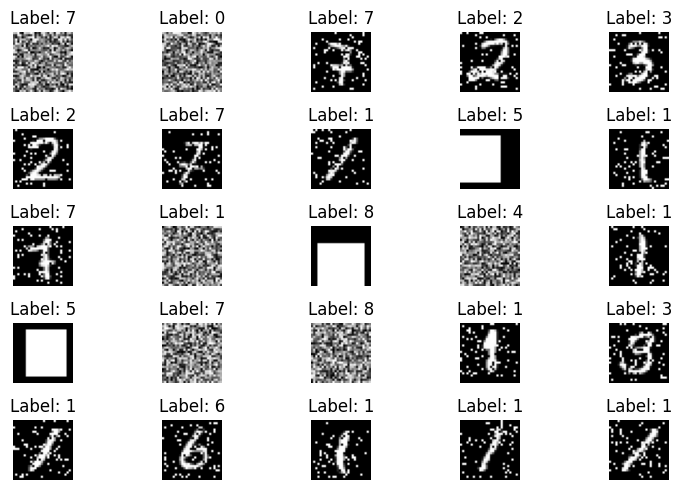

In [14]:
show_grid(dataset_wo_empty['train']['image'], dataset_wo_empty['train']['label'])

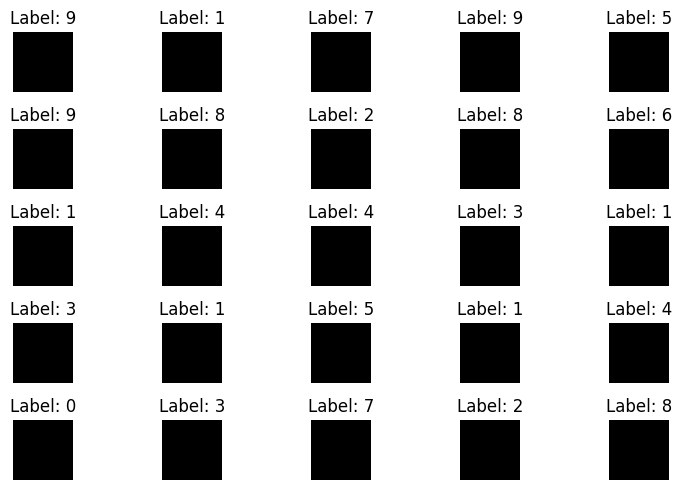

In [15]:
show_grid(empty_samples['train']['image'], empty_samples['train']['label'])

**Filter out noisy data (10 points)**

Implement **is_noisy** predicate.

Here we want to remove only images which contain **ONLY** noise. Images containing **digits** must remain in the dataset (even if they have some noise).

After filtering, take a look and make sure that noisy images have been filtered correctly: no noisy images in cleaned dataset and we didn't remove any images with digits.

You might consider looking at the distribution of pixel values, for example, through a histogram and think about whether some measure of its "spread" or "unpredictability" (such as entropy) could help distinguish noisy images.

Debug the function and find thresholds for params which will allow us filter the samples correctly.

Mind that images are stored in PIL format, you might want to convert them to numpy.


MDR : 
Two-condition rule:
**Noisy = high entropy AND no large connectent components**
- entropy: Noise-only images look like random noise
- Digit images still contain a coherent shape -> Large connected components
This will keep the digit images safe.

In [16]:
def is_noisy(sample, entropy_thr=6.0):
    img = np.array(sample["image"]).astype(np.uint8) #converting the image to np.array so we can perform numerical operations
    #uint8 ensures pixel values are in[0,255]

    hist = np.bincount(img.ravel(), minlength=256)
    #img.ravel() = flattens the image into 1D array of pixels
    #np.bincount() = counts the frequency of each pixel value
    #the result is a histogram of pixel intensities.
    prob = hist / hist.sum()
    #dividing by the total number of pixels, converts counts into probabilities
    
    prob = prob[prob > 0]
    #we remove bins that never occur in the image
    entropy = -(prob * np.log2(prob)).sum()
    #Shannon entropy formula
    #Entropy measures how unpredictable or random the pixel values are
    #So high entropy = random noise
    #Low entropy = structured image
    return entropy > entropy_thr
    #decides whethere the image is noisy or not

MDR:
We're now taking the dataset after empty images were removed.
- Applies the predicate function is_noisy to every sample
- Splits the datasets into two new datasets

In [17]:
dataset_wo_noisy, noisy_samples = filter_dataset(dataset_wo_empty, is_noisy)

Filter:   0%|          | 0/143706 [00:00<?, ? examples/s]

Filter:   0%|          | 0/24007 [00:00<?, ? examples/s]

Filter:   0%|          | 0/143706 [00:00<?, ? examples/s]

Filter:   0%|          | 0/24007 [00:00<?, ? examples/s]

MDR:
- Displays a grid of images from the cleaned training set
- Showing Images that were kept + their corresponding class labels.

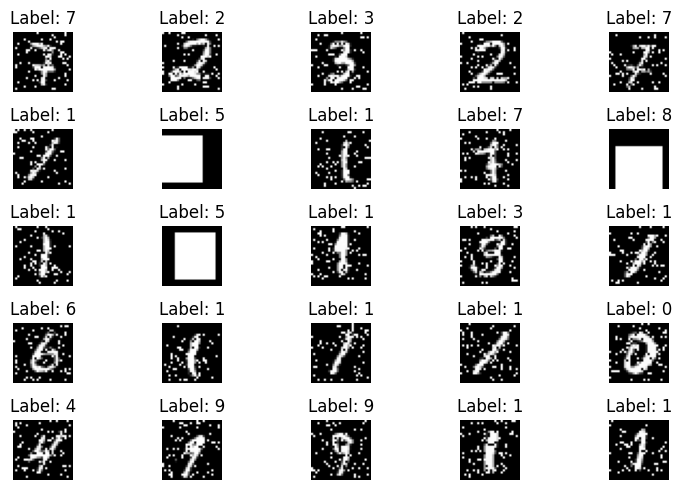

In [18]:
show_grid(dataset_wo_noisy['train']['image'], dataset_wo_noisy['train']['label'])

MDR :
Displaying a grid of images that were filtered out
- These images were classified as noise-only
- Labels are shown for inspection (-1 or meaningless)

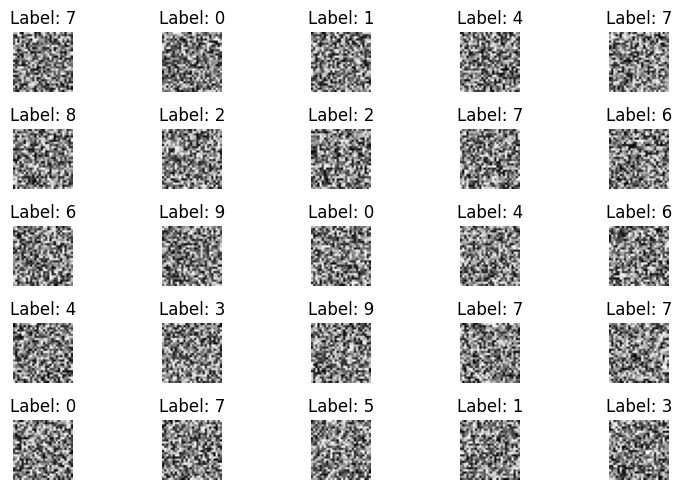

In [19]:
show_grid(noisy_samples['train']['image'], noisy_samples['train']['label'])

**Filter out samples with a large rectangle (5 points)**

Implement **has_large_rectangle** predicate.

Here we want to remove images which contain **large white rectangle**.

It can be detected using OpenCV methods or (**strongly suggested**) by binarizing images with a threshold and writing an algorithm to find borders of the rectangle, calculating its square and making a decision based on its size percentage relative to the entire image.

After filtering, take a look and make sure that noisy images have been filtered correctly: no noisy images in cleaned dataset and we didn't remove any images with digits.

Debug the function and find thresholds for params which will allow us filter the samples correctly.

Mind that images are stored in PIL format, you might want to convert them to numpy.

MDR:
The function detects large white rectangle artifacts by thresholding the image, identifying the bounding box of white pixels, and removing images where this box covers a large and solid portion of the image.


def has_large_rectangle(sample,white_thr=240,area_min=0.15,fill_min=0.90,outside_max=0.03):
    img = np.array(sample["image"]).astype(np.uint8)

    white = img > white_thr
    if white.sum() ==0:
        return False

    rows = np.where(white.any(axis=1))[0]
    cols = np.where(white.any(axis=0))[0]
    rmin, rmax = rows[0], rows[-1]
    cmin, cmax = cols[0], cols[-1]

    rect_area = (rmax-rmin+1)*(cmax-cmin+1)
    total_area = img.size
    area_ratio = rect_area / total_area

    #must be "large enough"

    if area_ratio < area_min:
        return False

    #rectangle should be mostly white inside
    inside = white[rmin:rmax+1,cmin:cmax+1]
    fill_ratio = inside.mean()
    if fill_ratio < fill_min:
        return False

    #and mostly isolated
    outside = white.copy()
    outside[rmin:rmax+1,cmin:cmax+1] = False
    outside_ratio = outside.mean() 
    if outside_ratio > outside_max:
        return False
    
    return True
    
    


In [20]:
from scipy.ndimage import binary_opening

def has_large_rectangle(sample, white_thr=200, area_min_ratio=0.15, solidity_thr=0.6):
    img = np.array(sample["image"]).astype(np.uint8)

    binary = img > white_thr

    clean_img = binary_opening(binary, structure = np.ones((2,2)))

    if clean_img.sum() == 0:
        return False

    rows = np.where(clean_img.any(axis=1))[0]
    cols = np.where(clean_img.any(axis=0))[0]
    rmin, rmax = rows[0], rows[-1]
    cmin, cmax = cols[0], cols[-1]

    #4. Calculate Geometric Metrics
    rect_h = rmax - rmin + 1
    rect_w = cmax - cmin + 1
    bb_area = rect_h * rect_w
    
    total_img_area = img.size
    
    #metric A: Is the object large enough relative to the whole image?
    if (bb_area / total_img_area) < area_min_ratio:
        return False

    #metric B: Solidity
    #handwritten digits are sparse (mostly black space inside their bounding box)
    #rectangles/Blocks are dense (mostly white space)
    pixel_count = clean_img.sum()
    solidity = pixel_count / bb_area

    # If it's large and dense (>60% filled), it's likely a block artifact
    if solidity > solidity_thr:
        return True

    return False
    

In [21]:
dataset_wo_rectangles, samples_with_rectangles = filter_dataset(dataset_wo_noisy, has_large_rectangle)

Filter:   0%|          | 0/113706 [00:00<?, ? examples/s]

Filter:   0%|          | 0/19007 [00:00<?, ? examples/s]

Filter:   0%|          | 0/113706 [00:00<?, ? examples/s]

Filter:   0%|          | 0/19007 [00:00<?, ? examples/s]

### P.S : compared to previous has_large_rectangle function, this performed best.

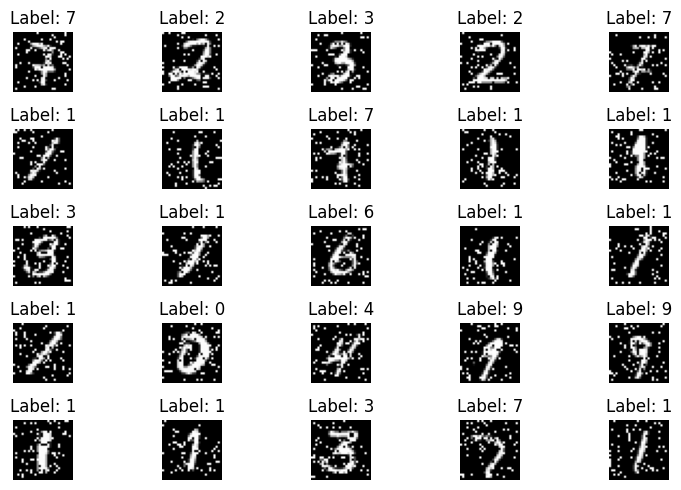

In [22]:
show_grid(dataset_wo_rectangles['train']['image'], dataset_wo_rectangles['train']['label'])

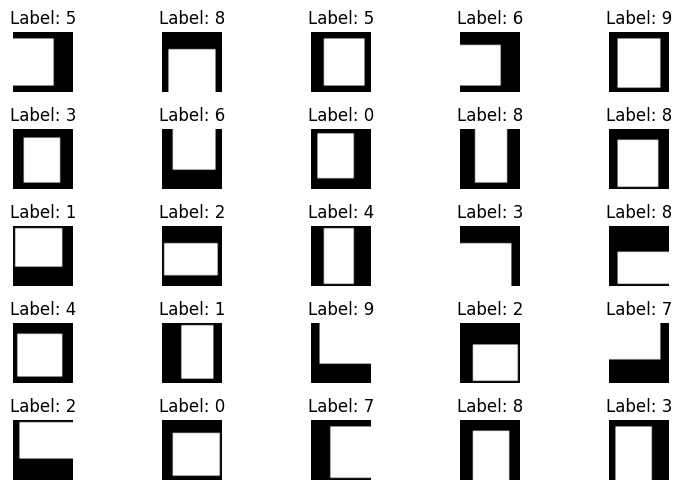

In [23]:
show_grid(samples_with_rectangles['train']['image'], samples_with_rectangles['train']['label'])

This is the final filtering step. Let's rename the ds to more convenient

In [24]:
filtered_ds = dataset_wo_rectangles

### Imbalance in Classes

From the visualization, you can observe an imbalance in the classes. To address this, consider applying techniques such as:

- **Oversampling**: Increase the number of samples in the minority class.
- **Undersampling**: Reduce the number of samples in the majority class.
- **Class Weighting**: Adjust model training by assigning different weights to classes. For most machine learning algorithms, class weighting is supported in **`sklearn`** by passing the `class_weight` parameter (see documentation e.g [Random Forest](https://scikit-learn.org/dev/modules/generated/sklearn.ensemble.RandomForestClassifier.html).
- **Data Augmentation**: Generate more diverse data for underrepresented classes by transforming existing samples. This can include techniques like rotating, scaling, or adding noise to the images.

Make sure to **learn about these techniques** and how to implement them effectively in your workflow.

You can perform these modifications directly on **PIL** images or by using augmentation libraries such as **Albumentations**. Be careful to ensure that the augmentations maintain the integrity of the images, and **do not apply any augmentations to the test set**.

**Ensure that you do not modify the test set when addressing class imbalance.**

**Apply oversampling or undersampling (5 points)**

Choose which approach to apply and analyse if it helps to achieve better metrics.


### MDR:
We're going for oversampling the minority classes (only in train)
This will help: 
- Keep the test split unchanged
- In the train split only, duplicate samples from slamm classes untill all classes have the same number as the largest class.

In [25]:
# you can address class imbalance here

from datasets import DatasetDict

def oversample_train_split(ds_dict, label_col="label", random_state=42):
    rng = np.random.default_rng(random_state)
    
    train = ds_dict["train"]
    labels = train[label_col]
    counts = Counter(labels)
    max_count = max(counts.values())

    idx_by_class = {}
    for i,y in enumerate(labels):
        idx_by_class.setdefault(y, []).append(i)

    new_indices = []
    for y, idxs in idx_by_class.items():
        idxs = np.array(idxs)
        if len(idxs) < max_count:
            extra = rng.choice(idxs, size= max_count - len(idxs), replace=True)
            idxs = np.concatenate([idxs, extra])
        new_indices.extend(idxs.tolist())

    rng.shuffle(new_indices)
    new_train = train.select(new_indices)
    
    out = DatasetDict({k:v for k, v in ds_dict.items()})
    out["train"] = new_train
    return out

dataset_balanced = oversample_train_split(dataset_wo_rectangles)


In [26]:
print(Counter(dataset_balanced['train']['label']))

Counter({4: 40372, 0: 40372, 2: 40372, 7: 40372, 3: 40372, 6: 40372, 1: 40372, 8: 40372, 5: 40372, 9: 40372})


## MDR:
We can Undersample the majority classes on train only but often it will hurt the performance of the model because we threw data away.

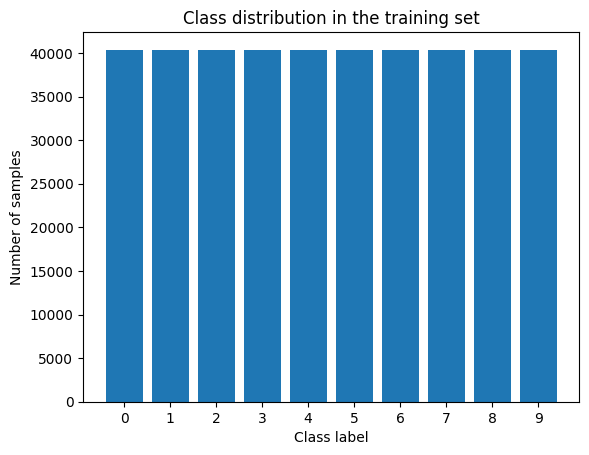

In [27]:
labels_1 = dataset_balanced["train"]["label"]
counts = Counter(labels_1)

classes = sorted(counts.keys())
values = [counts[c] for c in classes]

plt.bar(classes, values)
plt.xticks(classes)
plt.xlabel("Class label")
plt.ylabel("Number of samples")
plt.title("Class distribution in the training set")
plt.show()

**(ADV) Apply data augmentations (5 points)**

Apply data augmentations. Strongly recommended to display images for used augmentations and make sure the applied augmentations aren't too severe.

For example, vertical flip can make 6 and 9 indistinguishable. Avoid such situations.

In [28]:
# write code to apply data agumentations here. DO NOT APPLY IT TO TEST SET

from PIL import Image, ImageOps, ImageEnhance
import random
import numpy as np
def augment_pil(img, max_rotate=10, max_translate=2,brightness=(0.9,1.1),contrast=(0.9,1.1),noise_std=5):
    if not isinstance(img, Image.Image):
        img = Image.fromarray(np.array(img))

    # 1- Small rotation
    angle = random.uniform(-max_rotate, max_rotate)
    img = img.rotate(angle, resample=Image.BILINEAR, fillcolor=0)

    # 2- small translation
    dx = random.randint(-max_translate, max_translate)
    dy = random.randint(-max_translate, max_translate)
    img = ImageOps.expand(img, border=max_translate, fill=0)
    w,h = img.size
    img = img.crop((max_translate + dx, max_translate + dy,
                    max_translate + dx + (w - 2*max_translate),
                    max_translate + dy + (h - 2*max_translate)))

    # 3- brightness and contrast
    img = ImageEnhance.Brightness(img).enhance(random.uniform(*brightness))
    img = ImageEnhance.Contrast(img).enhance(random.uniform(*contrast))

    # 4- small Gaussian noise
    if noise_std and noise_std > 0 :
        arr = np.array(img).astype(np.float32)
        arr += np.random.normal(0, noise_std, size = arr.shape)
        arr = np.clip(arr, 0, 255).astype(np.uint8)
        img = Image.fromarray(arr)

    return img
    

In [29]:
import random
from datasets import Dataset, DatasetDict
def augment_train_only(ds_dict, k=1, seed=42):
    random.seed(seed)
    np.random.seed(seed)

    out = DatasetDict({k: v for k, v in ds_dict.items()})
    train = ds_dict["train"]

    augmented = []
    for sample in train:
        augmented.append(sample)

        for _ in range(k):
            new_sample = dict(sample)
            new_sample["image"] = augment_pil(sample["image"])
            augmented.append(new_sample)
            
    out["train"] = Dataset.from_list(augmented)
    #IMPORTANT: TEST/VALIDATION SETS REMAIN UNALTERED
    return out

dataset_aug = augment_train_only(dataset_wo_rectangles, k=1) # doubles train size

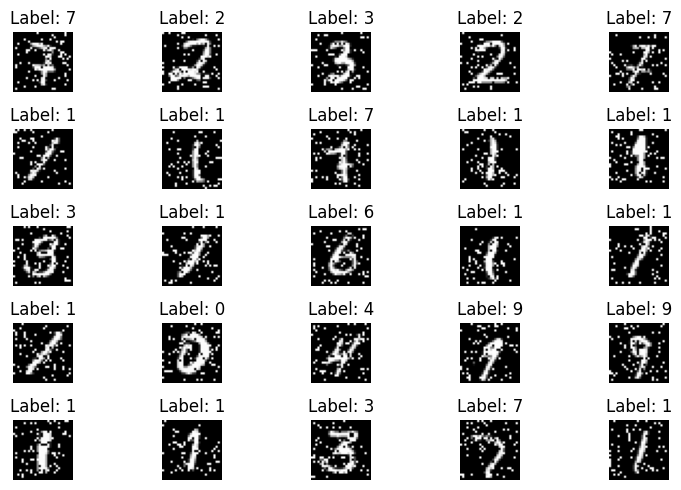

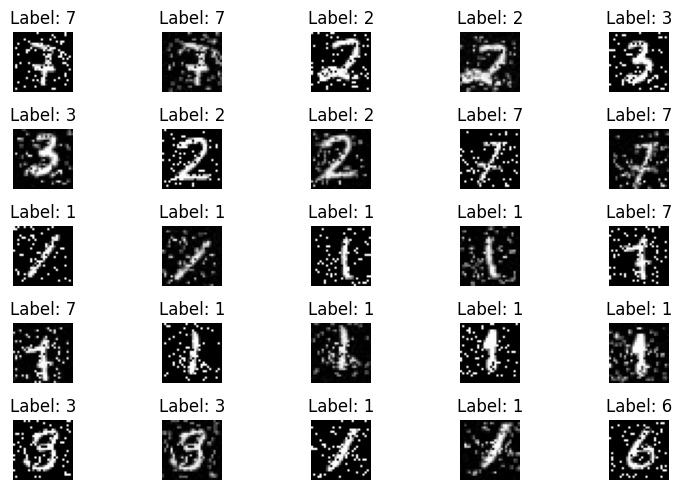

In [30]:
#original samples
show_grid(dataset_wo_rectangles["train"]["image"][:25],
          dataset_wo_rectangles["train"]["label"][:25])

#augmented samples
show_grid(dataset_aug["train"]["image"][:25],
          dataset_aug["train"]["label"][:25])


### Image Preprocessing

After filtering out junk samples, consider preprocessing the remaining images.

You could apply some of [image smoothing techniques](https://docs.opencv.org/3.4/d4/d13/tutorial_py_filtering.html) like: **averaging**, **gaussian** or **median blurring** to reduce noise -- noise added to these images has a name and has a standard way of reducing it, you can take a look at popular noises for example [here](https://medium.com/@Coursesteach/computer-vision-part-14-common-types-of-noise-7e6507cc763c). You may also try more advanced denoising techniques, though they might not work well on small images.

Also, [morphological transformations](https://docs.opencv.org/3.4/d9/d61/tutorial_py_morphological_ops.html) like **erosion**, **dilation**, and **opening/closing** can help with noise removal and feature enhancement.

However, none of these methods are guaranteed to provide a significant improvement.

**(ADV) Apply image preprocessing techniques to reduce impact of the noise (5 points)**

The noise added to the images has a special name and there is a standard technique to reduce it. Will be a plus if you identify it and will write short info about it.

##  Code: Train only preprocessing pipeline
### Median filter

In [31]:
from PIL import Image, ImageFilter

def denoise_pil_median(img, ksize=3):
    if not isinstance(img, Image.Image):
        img = Image.fromarray(np.array(img))
    return img.filter(ImageFilter.MedianFilter(size=ksize))

def preprocess_train_only(ds_dict, ksize=3):
    out = DatasetDict({k: v for k, v in ds_dict.items()})

    def _apply(example):
        example["image"] = denoise_pil_median(example["image"], ksize=ksize)
        return example
    
    out["train"] = ds_dict["train"].map(_apply)
    if "test" in ds_dict:
        out["test"] = ds_dict["test"]
    if "validation" in ds_dict:
        out["validation"] = ds_dict["validation"]
    return out

dataset_denoised = preprocess_train_only(dataset_wo_rectangles, ksize=3)

Map:   0%|          | 0/93618 [00:00<?, ? examples/s]

### Visual check
Showing original and denoised side by side

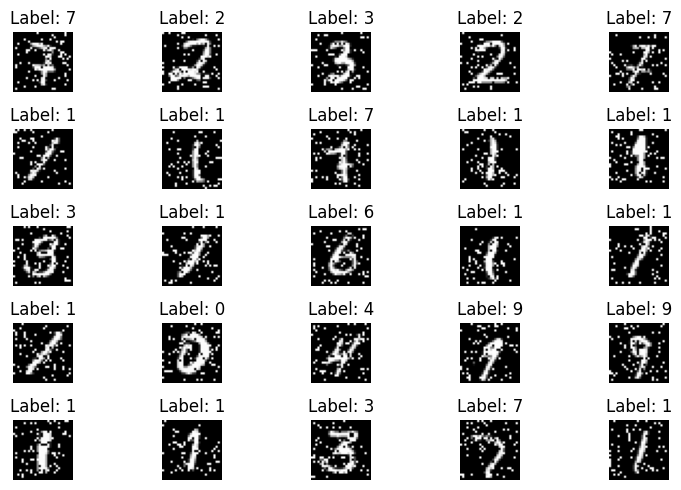

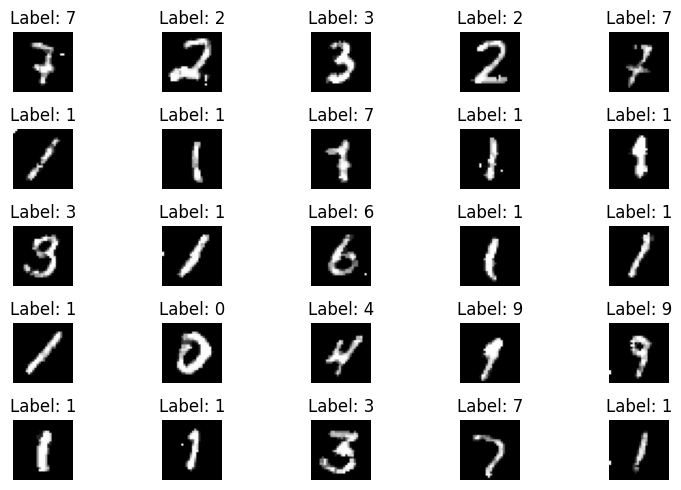

In [32]:
#original samples
show_grid(dataset_wo_rectangles["train"]["image"][:25],
          dataset_wo_rectangles["train"]["label"][:25])

#augmented samples
show_grid(dataset_denoised["train"]["image"][:25],
          dataset_denoised["train"]["label"][:25])


MDR : After removing invalid samples, we applied a preprocessing step to reduce noise in the remaining images. The noise present in the dataset resembles salt-and-pepper noise, which appears as isolated bright or dark pixels. To address this, we applied a median filter to the training images, as median filtering is a standard technique for reducing this type of noise while preserving important edges. The preprocessing was applied only to the training set, and the test set was left unchanged.

The preprocessing was applied only to the training set to avoid modifying the test data. The test set must remain untouched so that it represents unseen data and provides an unbiased evaluation of the model’s performance.

Let's preprocess the images into numpy array format and normalize it.

In [33]:
X_train = np.array([np.array(img) for img in filtered_ds['train']['image']])
y_train = np.array(filtered_ds['train']['label'])

X_test = np.array([np.array(img) for img in filtered_ds['test']['image']])
y_test = np.array(filtered_ds['test']['label'])

print(f"Train data shape: {X_train.shape}, Test data shape: {X_test.shape}")

X_train = X_train / 255.0
X_test = X_test / 255.0

Train data shape: (93618, 28, 28), Test data shape: (15658, 28, 28)


## Feature extraction

Now we will extarct features. Let's choose an image and take a look at some of the features.

In [34]:
image = X_train[6].reshape(28, 28)

**Average Pixel Intensity**

Average pixel intensity represents the mean value of all the pixel intensities in an image. This feature provides insight into the overall brightness or darkness of the digit.

**Standard Deviation of Pixel Intensity**

The standard deviation of pixel intensity measures how much variation there is in the pixel values of the image. A higher standard deviation indicates more contrast, while a lower value suggests more uniform pixel intensities.

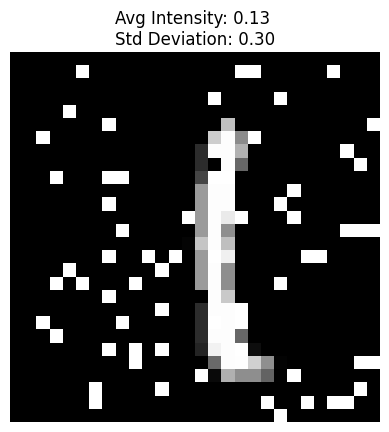

In [35]:
avg_intensity = np.mean(image)
std_intensity = np.std(image)

plt.imshow(image, cmap='gray')
plt.title(f"Avg Intensity: {avg_intensity:.2f} \nStd Deviation: {std_intensity:.2f}")

plt.axis('off')
plt.show()

**Pixel Intensity Histogram**

A pixel intensity histogram divides the pixel values into a set of K bins (here 10) and counts how many pixels fall into each bin. This provides a detailed distribution of pixel intensities.

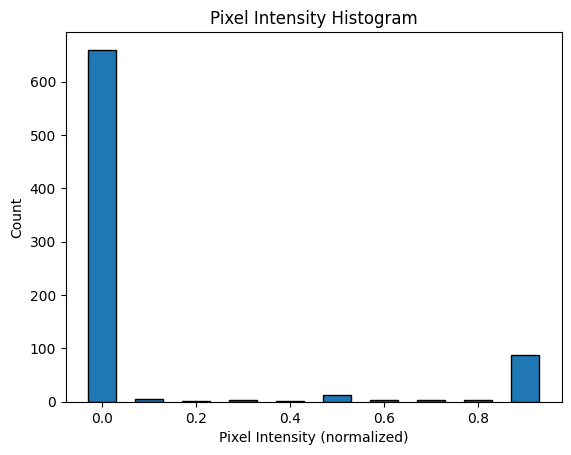

In [36]:
hist_pixels, bins = np.histogram(image, bins=10, range=(0, 1))

plt.bar(bins[:-1], hist_pixels, width=0.06, edgecolor="black")
plt.title("Pixel Intensity Histogram")
plt.xlabel("Pixel Intensity (normalized)")
plt.ylabel("Count")
plt.show()

**Horizontal and Vertical Projections**

Horizontal and vertical projections summarize the distribution of pixel intensities across the rows and columns of the image, respectively. These projections capture the overall structure and alignment of the digit along the horizontal and vertical axes. Horizontal projection sums the pixel intensities for each row, while vertical projection sums them for each column.

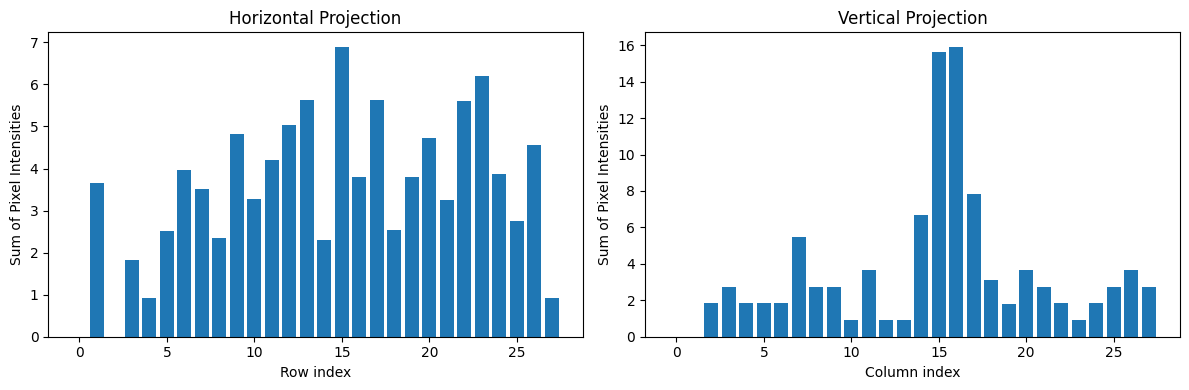

In [37]:
horizontal_projection = np.sum(image, axis=1)
vertical_projection = np.sum(image, axis=0)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.bar(range(len(horizontal_projection)), horizontal_projection)
plt.title("Horizontal Projection")
plt.xlabel("Row index")
plt.ylabel("Sum of Pixel Intensities")

plt.subplot(1, 2, 2)
plt.bar(range(len(vertical_projection)), vertical_projection)
plt.title("Vertical Projection")
plt.xlabel("Column index")
plt.ylabel("Sum of Pixel Intensities")

plt.tight_layout()
plt.show()

MDR: What does the graphs represent?

Well' focus on only Left plot: Horizontal projection:

- X-axis: row index (top to bottom of the image)
- Y-axis : sum of pixel intensities in that row

Interpretation:

- High bars indicate rows where the digit has more ink/strokes.
- Low bards indicate mostly background
- Captures the vertical structure of the digit


Try to extract other features like **symmetry**, [Local Binary Patterns (LBP)](https://en.wikipedia.org/wiki/Local_binary_patterns), [Histogram of Oriented Gradients (HOG)](https://builtin.com/articles/histogram-of-oriented-gradients), and [Hu Moments](https://learnopencv.com/tag/hu-moments/), available in *opencv* and *skimage*. These features capture texture, edges, shape, and structural balance in the image. You can also explore **pixel crossings** (the number of times a digit crosses the image's horizontal or vertical centerline).

Experimenting with these features can further improve your model's performance. **Self-learn about possible features** and try to apply them to your dataset for further experimentation.

Now we can write a function to extract features.

In [38]:
def extract_features(images):
    features = []
    for image in tqdm(images):
        image_reshaped = image.reshape(28, 28)

        # Average pixel intensity
        avg_intensity = np.mean(image_reshaped)

        # Standard deviation of pixel intensities
        std_intensity = np.std(image_reshaped)

        # Pixel intensity histogram
        hist_pixels, _ = np.histogram(image_reshaped, bins=10, range=(0, 1))

        # Horizontal and vertical projections
        horizontal_projection = np.sum(image_reshaped, axis=1)
        vertical_projection = np.sum(image_reshaped, axis=0)

        feature_vector = np.hstack([
            avg_intensity, 
            std_intensity,             
            hist_pixels,              
            horizontal_projection,    
            vertical_projection,      
        ])

        features.append(feature_vector)

    features_array = np.array(features)

    return features_array

**Implement a function to extract LBP - Local Binary Patterns (5 points)**

Write function to extract this feature, also add their description and discuss why it might be useful in this assignment.

Try to use it later in training.

# Local binary Patterns (LBP)
## Overview
Local Binary Patterns (LBP) is a simple yet efficient texture operator which labels the pixels of an image by thresholding the neighborhood of each pixel and considers the result as a binary number. Due to its discriminative power and computational simplicity, LBP has become a standard approach in computer vision for texture classification and face recognition.

### Key Characteristics:

- Gray-scale Invariant: Robust against monotonic changes in gray-scale (e.g., illumination variations).
- Rotation Invariant: Extensions exist to handle image rotation.
- Computational Efficiency: Relies on simple arithmetic and bitwise operations.

### Concept
The LBP feature vector, in its simplest form, is created in the following manner:

- Divide the examined window into cells (e.g. 16x16 pixels for each cell).
- For each pixel in a cell, compare the pixel to each of its 8 neighbors (on its left-top, left-middle, left-bottom, right-top, etc.). Follow the pixels along a circle, i.e. clockwise or counter-clockwise.
- Where the center pixel's value is greater than the neighbor's value, write "0". Otherwise, write "1". This gives an 8-digit binary number (which is usually converted to decimal for convenience).
- Compute the histogram, over the cell, of the frequency of each "number" occurring (i.e., each combination of which pixels are smaller and which are greater than the center). This histogram can be seen as a 256-dimensional feature vector.
- Optionally normalize the histogram.
- Concatenate (normalized) histograms of all cells. This gives a feature vector for the entire window.

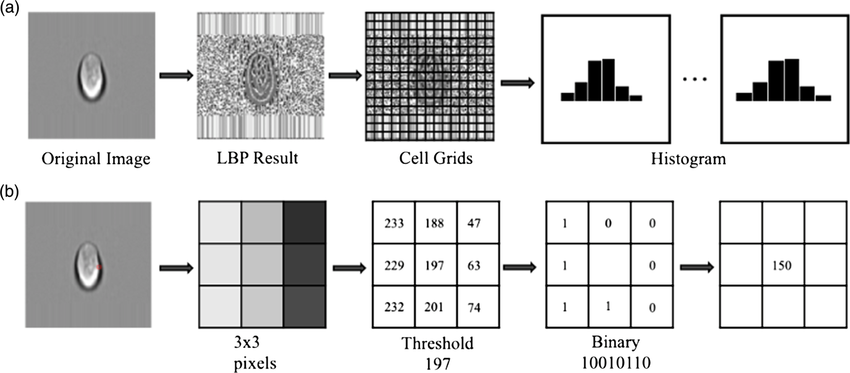

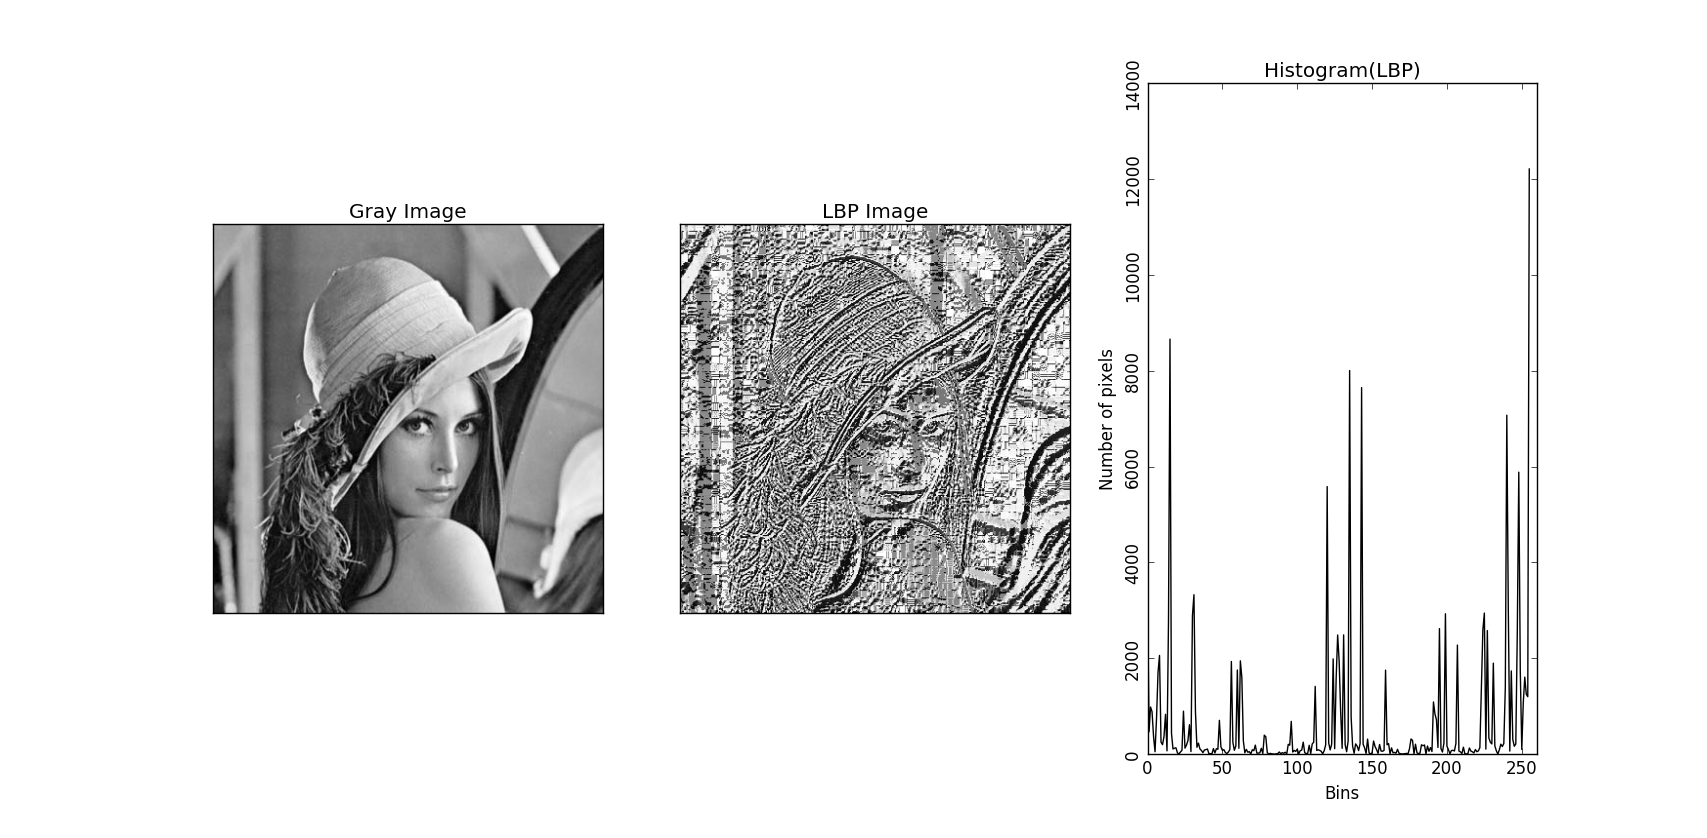

In [41]:
def extract_lbp(images, radius=1, method="uniform", normalize=True):

    P = 8 * radius  #number of points
    n_bins = (P + 2) if method == "uniform" else (2 ** P)

    features = []
    for img in tqdm(images):
        arr = np.array(img)

        #ensure 2D shape
        if arr.ndim == 1:
            arr = arr.reshape(28,28)

        #LBP expects grayscale images; convert to float for safety
        arr = arr.astype(np.float32)
        
        lbp = local_binary_pattern(arr, P=P, R=radius, method=method)

        #histogram
        hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins))
        if normalize:
            hist = hist.astype(np.float32)
            if hist.sum() > 0:
                hist /= hist.sum()
        
        features.append(hist)
    return np.array(features)
        
        
        

**Explore and add other features useful for classification (10 points)**

It can be in a single function or in separated functions. Select some features and provide a description for each one. You can choose as many features as you like.

# Edge map + Edge density

## Edge map
Edge map features are extracted to highlight the structural boundaries of the digits. Using an edge detection algorithm, the image is transformed into a binary map where pixels corresponding to intensity discontinuities (edges) are emphasized. This representation captures the shape and contour information of the digits, which is less sensitive to illumination changes and background noise. The resulting edge map is flattened and used as part of the feature vector to help the classifier distinguish digits based on their outlines and stroke structure.


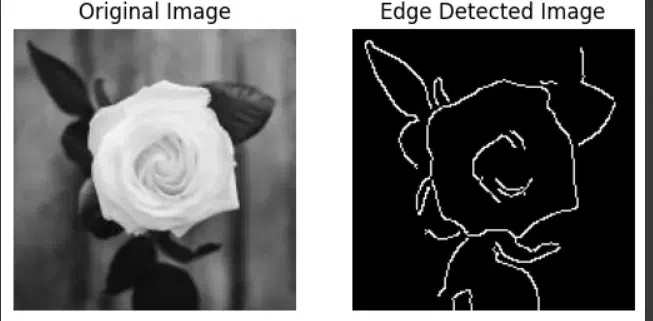

In [42]:
def extract_edge_map(images, low_thresh=50, high_thresh=150):
    """
    Extract flattened edge maps using Canny.
    Returns shape: (n_samples, n_pixels)
    """
    features = []

    for img in tqdm(images):
        arr = np.array(img, dtype=np.uint8)

        if arr.ndim == 1:
            arr = arr.reshape(28, 28)

        if arr.max() <= 1.0:
            arr = (arr * 255).astype(np.uint8)

        edges = cv2.Canny(arr, low_thresh, high_thresh)

        features.append(edges.flatten())

    return np.array(features, dtype=np.float32)

## Edge Density

Edge density measures the proportion of edge pixels relative to the total number of pixels in an image. After computing the edge map, the number of pixels identified as edges is counted and normalized by the image size. This single-value feature provides a compact summary of how complex or detailed a digit is, as digits with more strokes and intersections tend to produce higher edge densities. It complements the full edge map by adding a global structural descriptor.

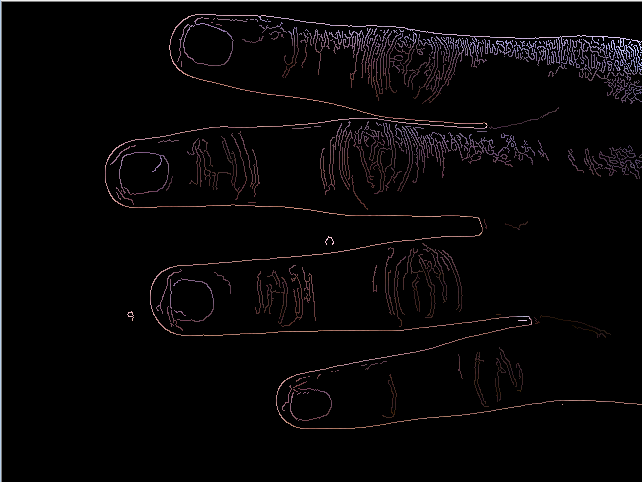

In [44]:
def extract_edge_density(images, low_thresh=50, high_thresh=150):
    """
    Computes edge density for each image using Canny edge detection.

    Returns:
        np.ndarray of shape (n_samples, 1)
    """
    edge_densities = []

    for img in tqdm(images):
        # Ensure image is uint8 for OpenCV
        img_uint8 = (img * 255).astype(np.uint8)

        # Compute edge map
        edges = cv2.Canny(img_uint8, low_thresh, high_thresh)

        # Edge density = ratio of edge pixels
        density = np.sum(edges > 0) / edges.size
        edge_densities.append([density])

    return np.array(edge_densities)

# Histogram of Oriented Gradients (HOG)

## Overview
The Histogram of Oriented Gradients (HOG) is a feature descriptor used in computer vision and image processing for the purpose of object detection. It characterizes the shape and appearance of an object by counting the occurrences of gradient orientation in localized portions of an image.

## Key characteristics
- **Edge-Based**: Captures local shape information using intensity gradients.
- **Geometric invariance**: The use of local histograms makes it invariant to small geometric deformations such as translation, rotation, and scale.
- **Illumination Invariance**: Block-wise normalization ensures robustness to changes in illumination and contrast.
- **Primary Application**: Originally proposed for human/pedestrian detection, it is widely used for general object recognition.

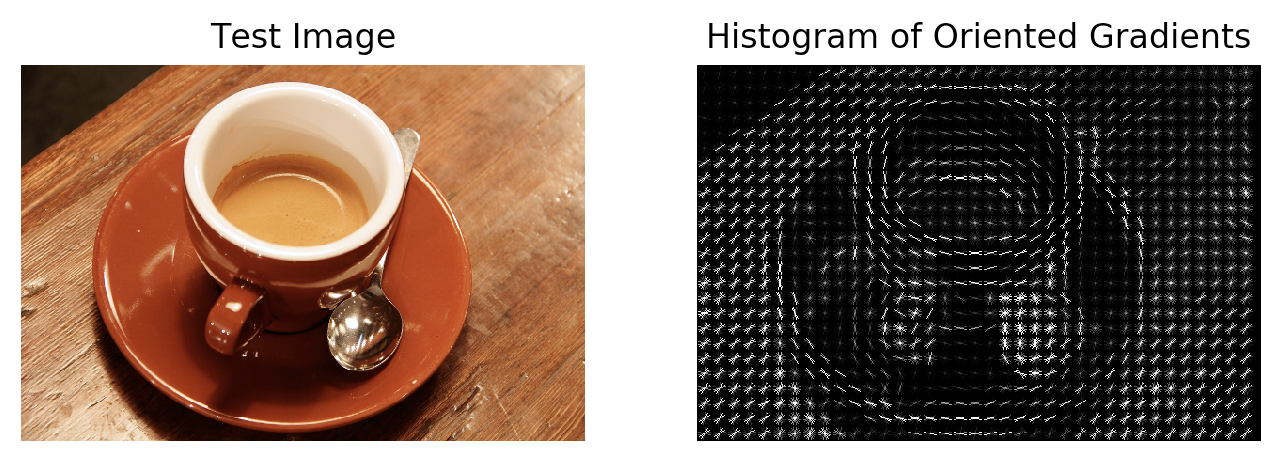
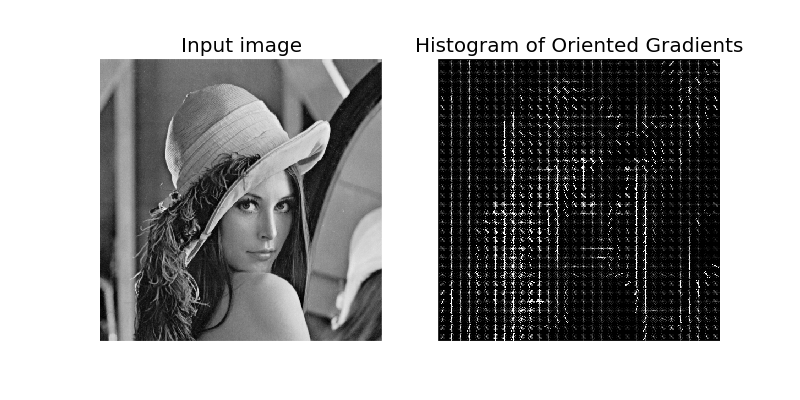


In [45]:
def extract_hog(images, orientations=9, pixels_per_cell=(4,4), cells_per_block=(2,2),block_norm="L2-Hys"):
    features = []
    for img in tqdm(images):
        arr = np.array(img, dtype=np.float32)

        if arr.ndim == 1:
            arr = arr.reshape(28, 28)

        if arr.max() > 1.0:
            arr /= 255.0

        hog_vec = hog(
            arr,
            orientations=orientations,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            block_norm=block_norm,
            feature_vector=True,
        )
        features.append(hog_vec)
    return np.array(features, dtype=np.float32)


# Global Reflection Symmetry

## Overview
Global Reflection Symmetry (also known as bilateral or mirror symmetry) is a geometric feature that quantifies the degree to which an image is invariant to reflection across a specific axis—typically the vertical mid-line for object detection tasks (e.g., faces, vehicles).

Unlike local features (like LBP) that describe texture, Global Reflection Symmetry describes the holistic structural arrangement of the image data.

## Key applications:
- **Global Descriptor**: Considers the entire region of interest (ROI) rather than small patches.
- **Continuous Measure**: Instead of a binary "symmetric/not symmetric" classification, it provides a score (0 to 1) indicating the degree of symmetry.
- **Orientation Dependent**: Standard implementation assumes a vertical axis of symmetry, requiring the image to be roughly aligned.



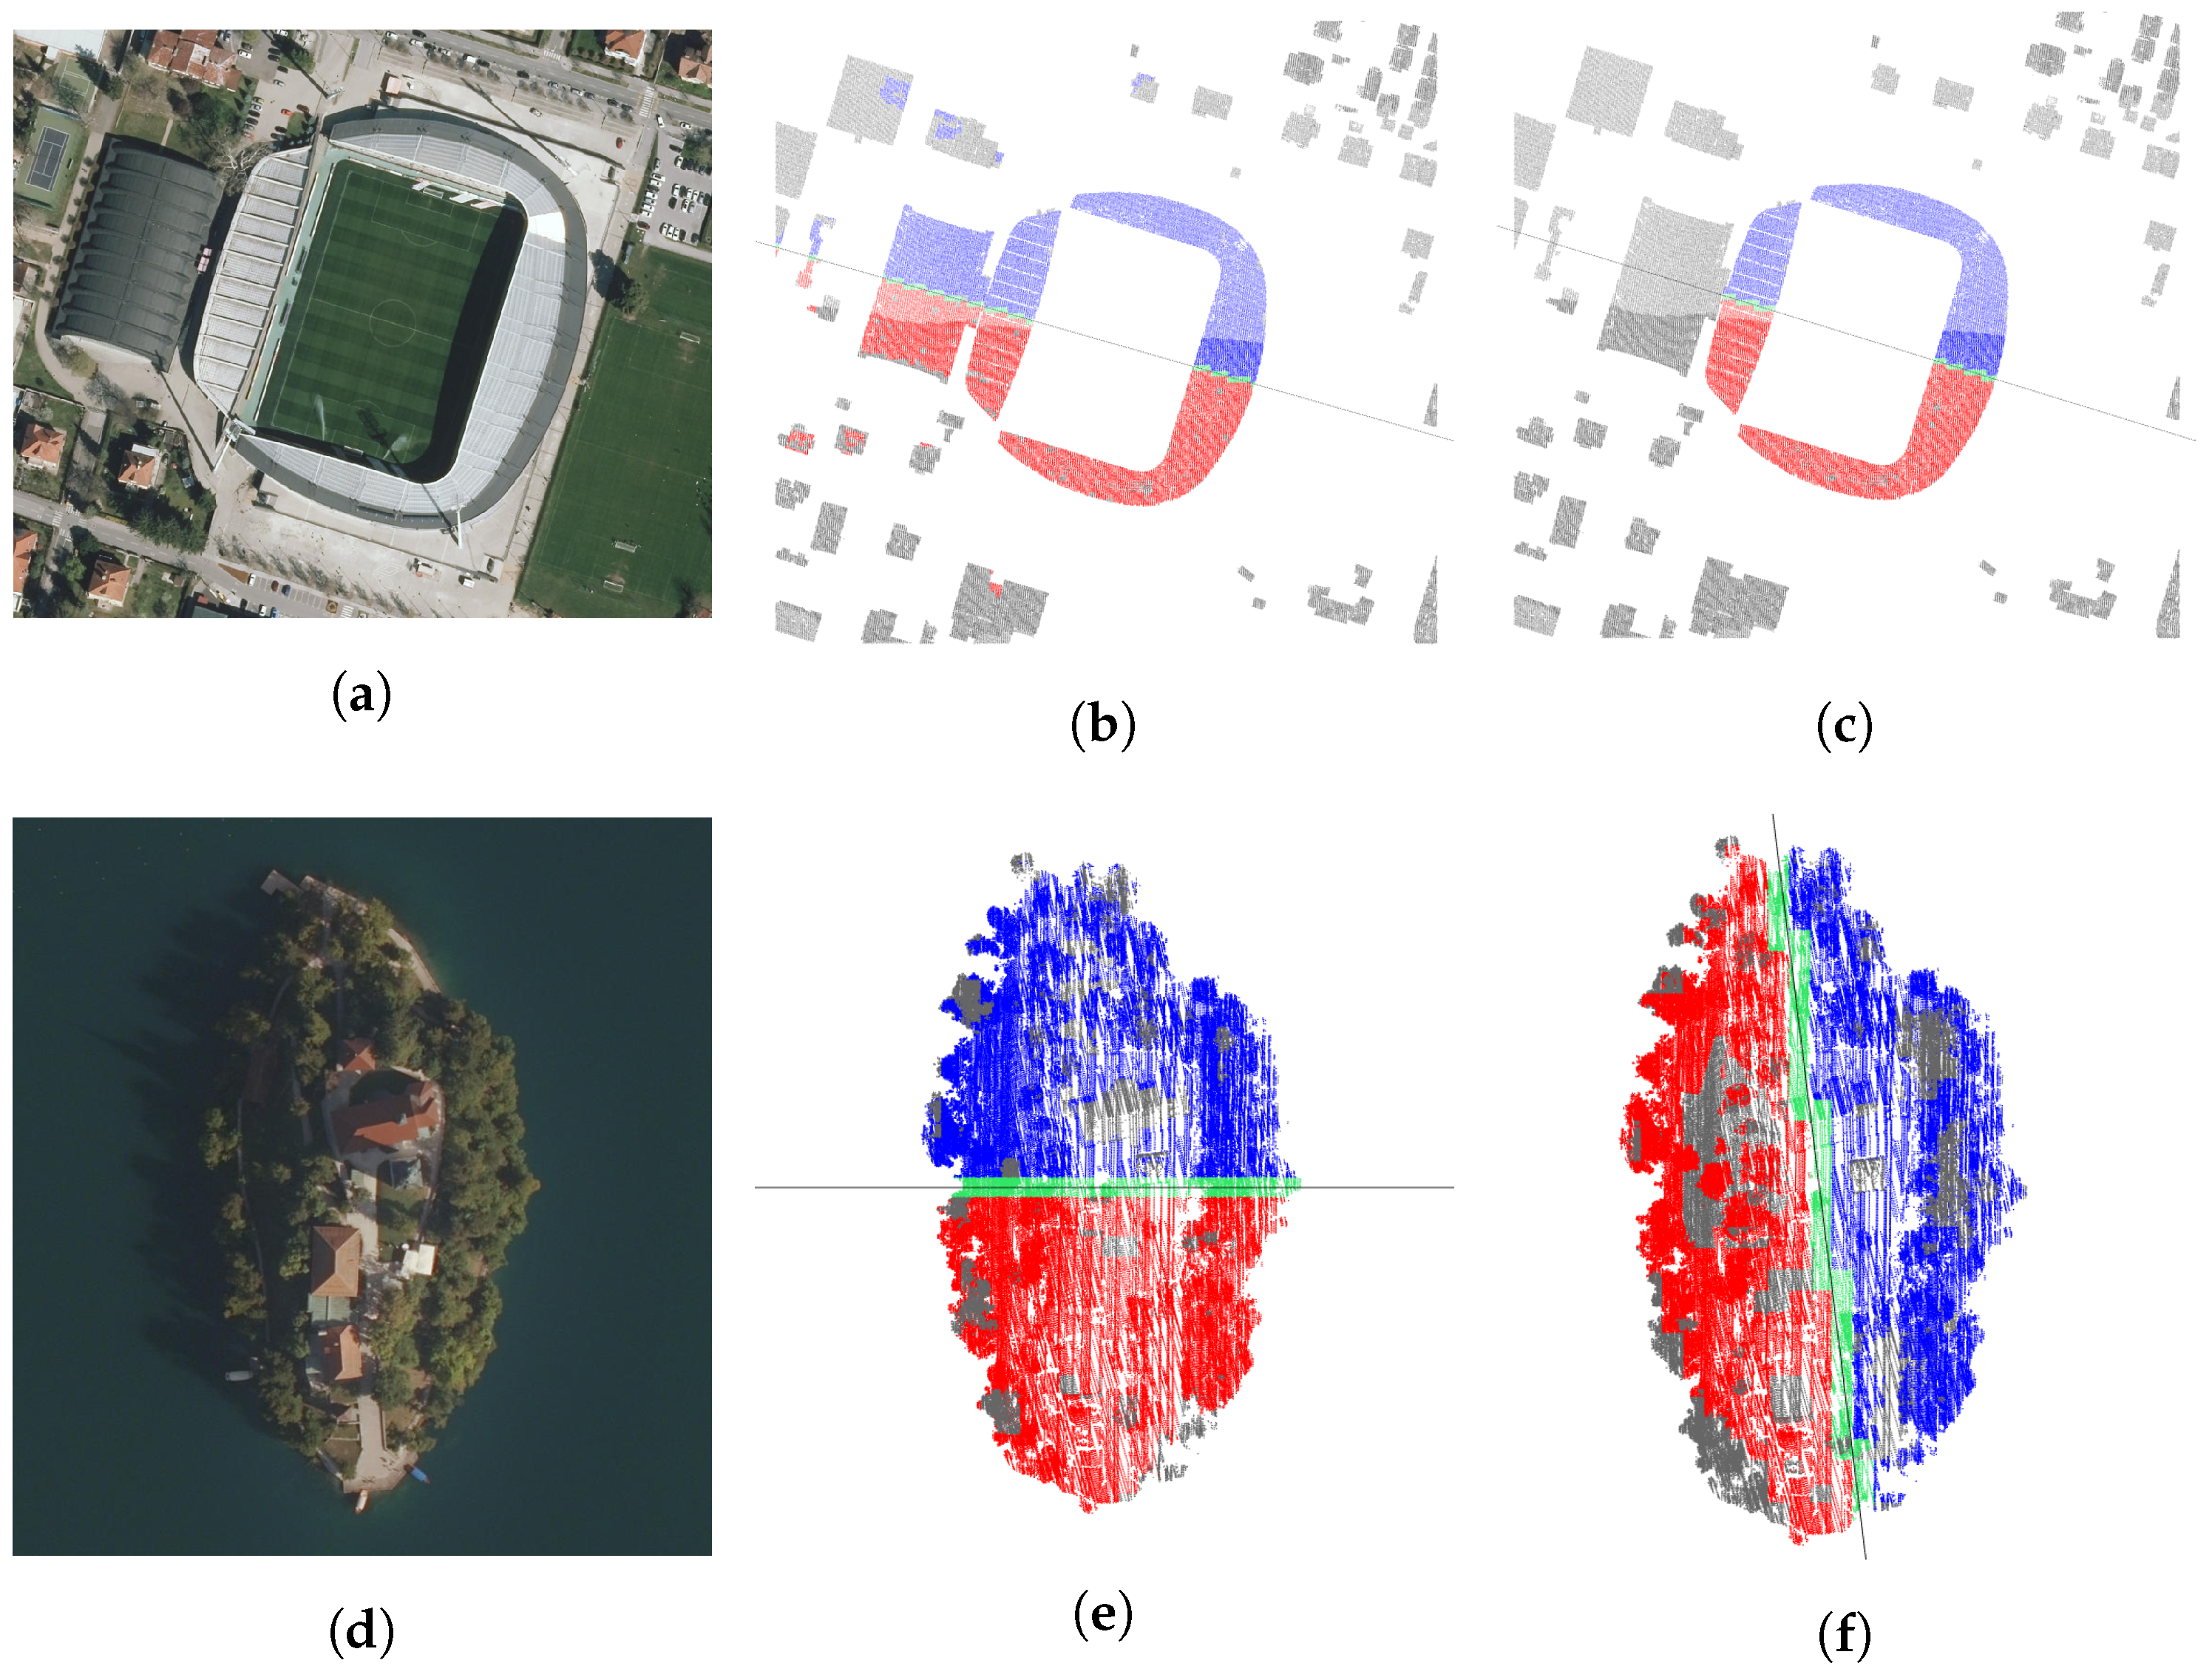

In [46]:
def extract_symmetry_features(images, eps=1e-8):
    """
    Returns a (n_samples, 2) feature matrix:
       - col 0 : left-right symmetry score
       - col 1 : top-bottom symmetry score
    
    Score are normalized to [0, 1], where 1 means more symmetric.
    """
    feats = []

    for img in tqdm(images):
        arr = np.array(img, dtype=np.float32)

        #ensure 2D
        if arr.ndim == 1:
            arr = arr.reshape(28, 28)
        
        #normalize if pixels are in [0..255], leave if in [0..1]
        if arr.max() > 1.0:
            arr /= 255.0

        lr_flips = np.fliplr(arr)
        tb_flips = np.flipud(arr)
        
        lr_diff = np.mean(np.abs(arr - lr_flips))
        tb_diff = np.mean(np.abs(arr - tb_flips))

        #convert differences into similarity scores (higher is better)
        # the denominator rescales by overall "ink" magnitude so blank-ish images don't dominate.

        scale = np.mean(np.abs(arr)) + eps

        lr_score = 1.0 - (lr_diff / (2.0 * scale))
        tb_score = 1.0 - (tb_diff / (2.0 * scale))

        lr_score = float(np.clip(lr_score, 0.0, 1.0))
        tb_score = float(np.clip(tb_score, 0.0, 1.0))

        feats.append([lr_score, tb_score])

    return np.array(feats, dtype=np.float32)
        
        
        

Now let's apply the function and extract features. Consider, it can take some time (especially if you didn't filter out junk samples).

# Extract and combine features - All

In [47]:
# 1) Basic
X_train_basic = extract_features(X_train)
X_test_basic  = extract_features(X_test)

# 2) Edge map
X_train_edge_map = extract_edge_map(X_train)
X_test_edge_map  = extract_edge_map(X_test)

# 3) Edge density
X_train_edge_density = extract_edge_density(X_train)
X_test_edge_density = extract_edge_density(X_test)

# 4) LBP
X_train_lbp = extract_lbp(X_train)
X_test_lbp  = extract_lbp(X_test)

# 5) HOG
X_train_hog = extract_hog(X_train)
X_test_hog  = extract_hog(X_test)

# 6) Symmetry
X_train_sym = extract_symmetry_features(X_train)
X_test_sym  = extract_symmetry_features(X_test)

# Final feature vectors
X_train_features = np.hstack([
    X_train_basic,
    X_train_lbp,
    X_train_hog,
    X_train_sym
])

X_test_features = np.hstack([
    X_test_basic,
    X_test_lbp,
    X_test_hog,
    X_test_sym
])

print("Basic :", X_train_basic.shape, X_test_basic.shape)
print("LBP :  ", X_train_lbp.shape, X_test_lbp.shape)
print("HOG :  ", X_train_hog.shape, X_test_hog.shape)
print("Sym :  ", X_train_sym.shape, X_test_sym.shape)
print("FINAL :", X_train_features.shape, X_test_features.shape)

# TO ME : #REMEMBER TO PUT BACK THE EDGE MAP/DENSITY IN TRAIN AND TEST
#DONE

  0%|          | 0/93618 [00:00<?, ?it/s]c:\Users\agood\AppData\Local\Programs\Python\Python312\Lib\site-packages\skimage\feature\texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(
100%|██████████| 15658/15658 [00:00<00:00, 20179.92it/s]


Basic : (93618, 68) (15658, 68)
LBP :   (93618, 10) (15658, 10)
HOG :   (93618, 1296) (15658, 1296)
Sym :   (93618, 2) (15658, 2)
FINAL : (93618, 1376) (15658, 1376)


## Model training

Let's create a pipeline and fit it

In [48]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train_features, y_train)

,steps,"[('scaler', ...), ('log_reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


Now we can evaluate the model on the test set

Model Accuracy: 0.9487
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       979
           1       0.99      0.99      0.99      6797
           2       0.91      0.91      0.91      1032
           3       0.90      0.92      0.91      1010
           4       0.92      0.92      0.92       982
           5       0.91      0.91      0.91       892
           6       0.94      0.95      0.95       958
           7       0.91      0.92      0.92      1028
           8       0.91      0.90      0.91       971
           9       0.90      0.89      0.90      1009

    accuracy                           0.95     15658
   macro avg       0.92      0.93      0.93     15658
weighted avg       0.95      0.95      0.95     15658



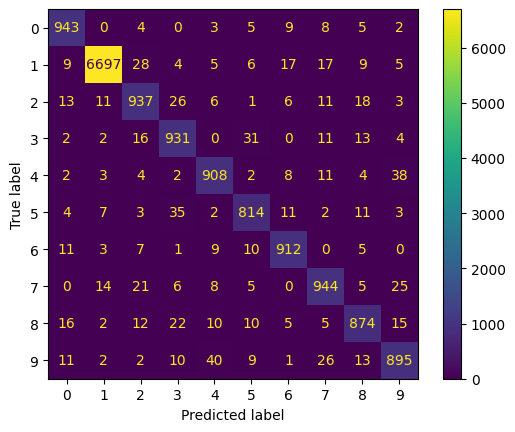

In [49]:
y_pred = pipeline.predict(X_test_features)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

ConfusionMatrixDisplay.from_estimator(pipeline, X_test_features, y_test)
plt.show()

**Train other models and compare their performance (10 points)**

Try training different models (at least 3) from sklearn and boosting libraries (e.g. Random Forest, SVM, Gradient Boosting, etc)

### SVM with RBF Kernel

In [50]:
# write your code here
from sklearn.svm import SVC

pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel="rbf", C=5, gamma="scale"))
])

pipeline_svm.fit(X_train_features, y_train)
y_pred = pipeline_svm.predict(X_test_features)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9653851066547452


### Random Forest

In [51]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_features, y_train)
y_pred = rf.predict(X_test_features)
print("Accuracy: ", accuracy_score(y_test, y_pred))


Accuracy:  0.9358155575424703


### Gradient Boosting
We used a much faster implementation inspired by LightGBM. It groups continuous features into "bins" (histograms), reducintg the complexity from $O(N \times \log N)$ to $O(N)$.

In [52]:
from sklearn.ensemble import HistGradientBoostingClassifier

hgb = HistGradientBoostingClassifier(
    max_iter=300, 
    learning_rate=0.05, 
    early_stopping=True
)

hgb.fit(X_train_features, y_train)
y_pred = hgb.predict(X_test_features)
print("Accuracy: ", accuracy_score(y_test, y_pred))

Accuracy:  0.968450632264657


**(ADV) Choose several best models and perform parametric grid search (5 points)**

Choose several of the best-performing models from your previous experiments and tune their hyperparameters using a parametric grid search. Compare the results and discuss which combination performs best.

In [53]:
from sklearn.experimental import enable_halving_search_cv 
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# (speeds up the process significantly compared to the default 200MB)
svm = SVC(cache_size=1000) 


param_grid_svm = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.01, 0.001],
    "kernel": ["rbf"]
}

# 4. Use HalvingGridSearchCV instead of GridSearchCV
search = HalvingGridSearchCV(
    svm,
    param_grid_svm,
    cv=3,                
    factor=3,             
    scoring="accuracy",
    n_jobs=-1,            
    verbose=1  
)


print("Starting optimized training...")
search.fit(X_train_features, y_train)

# 6. Predict and Evaluate
best_model = search.best_estimator_
y_pred_svm = best_model.predict(X_test_features)

print("Best SVM parameters:", search.best_params_)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

Starting optimized training...
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 10402
max_resources_: 93618
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 9
n_resources: 10402
Fitting 3 folds for each of 9 candidates, totalling 27 fits
----------
iter: 1
n_candidates: 3
n_resources: 31206
Fitting 3 folds for each of 3 candidates, totalling 9 fits
----------
iter: 2
n_candidates: 1
n_resources: 93618
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best SVM parameters: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
SVM Accuracy: 0.9452675948396986


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Reduce memory
X_train_features = X_train_features.astype(np.float32)
X_test_features  = X_test_features.astype(np.float32)

rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    "n_estimators": [200],
    "max_depth": [20, 40],
    "min_samples_split": [2]
}

grid_rf = GridSearchCV(
    rf,
    param_grid_rf,
    cv=5,
    scoring="accuracy",
    n_jobs=1
)

grid_rf.fit(X_train_features, y_train)

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test_features)

print("Best RF parameters:", grid_rf.best_params_)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
#WE IGNORED THIS PART BECAUSE IT TOOK TOO LONG TO RUN


KeyboardInterrupt: 

In [56]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score


hgb = HistGradientBoostingClassifier(random_state=42, early_stopping=True)

param_grid_hgb = {
    "max_iter": [100, 200],          
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5]
}

grid_hgb = GridSearchCV(
    hgb,
    param_grid_hgb,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

print("Starting HistGradientBoosting training...")
grid_hgb.fit(X_train_features, y_train)

best_hgb = grid_hgb.best_estimator_
y_pred_hgb = best_hgb.predict(X_test_features)

print("Best Parameters:", grid_hgb.best_params_)
print("HistGradientBoosting Accuracy:", accuracy_score(y_test, y_pred_hgb))

Starting HistGradientBoosting training...
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'max_iter': 200}
HistGradientBoosting Accuracy: 0.9669178694597012


**(ADV) Make the same experiments with some of the best models using cross validation (5 points)**

Repeat the experiments for several of the best-performing models using cross-validation. Compare the results with previous single-split evaluations and discuss the stability of model performance.

In [ ]:
# write your code here

**(ADV) Apply class weighting (5 points)**

Apply class weghting and check its effect. When we discussed dealing with data imbalance, we discussed also this technique. Try to apply it.

## Assignment

**Please use only the provided dataset: no external datasets are allowed.**

**Use train subset only for training and test only for testing, and make sure not removing relevant samples during data cleaning/preprocessing.**

**Your report must contain also your comments, thoughts and conclusions.**


**The solution notebook MUST run without errors when executing all cells.**

Focus only on classical machine learning algorithms available in *sklearn* for your analysis, other than artificial neural networks.

You are welcome to experiment with models based on artificial neural networks, but these will not be evaluated.

### Tasks

1. **Data Visualization and Exploration**:
   - Visualize and analyze the dataset to gain insights into the distribution and characteristics of different features.
   - Consider visualizing the distribution of labels, pixel intensity distributions, and any additional features you extract.
   - After applying each filtering approach (e.g., removing irrelevant or noisy data), visualize how the data changes to verify the effectiveness of your method.
   - Analyze correlations between features to understand which ones are most important for classification and identify any redundant or highly correlated features.

2. **Handle Unlabeled and Irrelevant Data**:
   - Investigate the dataset for **unlabeled** data.
   - Identify and filter out **irrelevant images**, such as:
     - Empty images
     - Images containing white noise
     - Images containing only a large rectangle
   - Be careful when handling this noisy data, as it may affect model performance if not properly filtered.

3. **Feature Engineering and Preprocessing**:
   - Experiment with adding new features or refining the ones already provided (e.g., symmetry, pixel intensity histograms, edge detection).
   - Deal with **class imbalance** using methods such as oversampling, undersampling, class weighting, or data augmentation. Ensure you do not modify the test set when addressing class imbalance.
   - All images in the dataset contain slight noise. You may want to try applying denoising techniques (i.e. **median blur**, **Gaussian blur**, or **light smoothing filters**) to improve the quality of the input data.
   - Learn about and adjust feature extraction techniques to better capture the characteristics of the images and improve model performance.

4. **Apply Different Machine Learning Algorithms**:
   - Try various [machine learning algorithms](https://scikit-learn.org/1.5/supervised_learning.html) (e.g., Random Forest, SVM, k-Nearest Neighbors, Logistic Regression) to improve performance.
   - Evaluate the models not only based on the **overall accuracy**, but also consider the confusion matrix and **per-class performance**.
   - Compare and explain the effect of using different evaluation [metrics](https://scikit-learn.org/1.5/modules/model_evaluation.html) (e.g., precision, recall, F1-score) based on your findings from the exploratory data analysis.

## Assignment Evaluation Criteria (maximum 100)

1. **Data Handling and Preprocessing (5 + 10 + 5 = 20 points)**
2. **Exploratory Data Analysis (5 points)**
3. **Feature Engineering (5 + 5 + 5 + 5 + 10 = 30 points)**
4. **Model Selection and Comparison (10 + 5 + 5 + 5 = 25 points)**
6. **Clarity, Creativity, and Originality (20 points)**



## Assignment submission instructions
Complete the assignment in your own copy of the notebook. Ensure that your notebook is runnable and free of errors. Once finished, test out the notebook in Goggle Colab (to make sure it runs in that environment too). Then RUN-ALL the project and export both the **.ipynb** file and the static notebook (**PDF** OR **html**) file. Finally, submit both files via the Teams Assignment section (do not zip the files).

**The deadline is 14 days ahead of the oral exam.**

**Actual deadlines are updated in the Teams Assignment Portal.**